In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, OPTICS, cluster_optics_dbscan
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import MultiLabelBinarizer

## Distance matrix

In [3]:
df = pd.read_csv("../results/train_clean.csv", index_col=0)

In [4]:
df['countryOfOrigin'] = df['countryOfOrigin'].apply(ast.literal_eval)
df['genres'] = df['genres'].apply(ast.literal_eval)

In [5]:
mbl = MultiLabelBinarizer()
countries_df = pd.DataFrame(mbl.fit_transform(df['countryOfOrigin']), columns=mbl.classes_, index=df.index)
countries_df = countries_df.astype('bool')
most_fr_countries = countries_df.sum().sort_values(ascending=False)

In [6]:
countries_df = countries_df[most_fr_countries.head(4).index]
countries_df.head()

,US,GB,JP,FR
0,True,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False


In [7]:
genres_df = pd.DataFrame(mbl.fit_transform(df['genres']), columns=mbl.classes_, index=df.index)
genres_df = genres_df.astype('bool')

In [8]:
numeric_cols = df.dtypes[(df.dtypes == 'float64') | (df.dtypes == 'int64')].index
numeric_df = df[numeric_cols]
numeric_df['logRuntime'] = np.log(numeric_df['runtimeMinutes'] + 1)
numeric_df.drop(['ratingNum', 'runtimeMinutes'], axis=1, inplace=True)
numeric_df.head()

/tmp/ipykernel_197741/1837241945.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numeric_df['logRuntime'] = np.log(numeric_df['runtimeMinutes'] + 1)
/tmp/ipykernel_197741/1837241945.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  numeric_df.drop(['ratingNum', 'runtimeMinutes'], axis=1, inplace=True)


,startYear,numVotes,totalImages,totalCredits,numRegions,numGenres,criticReviewsRatio,logRuntime
0,1995,6.659294,0.693147,3.091042,0.693147,3,1.000000,3.713572
1,1982,2.484907,0.693147,0.693147,0.693147,1,0.000000,3.367296
2,1992,3.663562,0.693147,3.218876,0.693147,1,0.000000,4.510860
3,2021,2.772589,3.135494,4.043051,0.693147,1,0.000000,3.465736
4,2020,9.662625,5.852202,3.871201,3.496508,3,0.008772,4.394449


In [9]:
title_df = pd.get_dummies(df['titleType'], columns=['titleType'], drop_first=True)
title_df.head()

,short,tvEpisode,tvMiniSeries,tvMovie,tvSeries,tvShort,tvSpecial,video,videoGame
0,False,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False
4,False,False,False,False,True,False,False,False,False


In [10]:
bool_cols = df.dtypes[df.dtypes == 'bool'].index
bool_df = df[bool_cols]
bool_df.head()

,canHaveEpisodes,awardsAndNominations,hasVideos,moreCountriesOfOrigin
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,True,False,False,False
4,True,True,True,False


In [11]:
scaler = StandardScaler()
numeric_df = scaler.fit_transform(numeric_df)

We use exactly the same distance matrix used for hierarchical clustering in order to have comparable results for the two families of algorithms.
Euclidean distance on numerical features and jaccard distance on the boolean features `canHaveEpisodes`, `awardsAndNominations`, `hasVideos`, `moreCountriesOfOrigin`

In [12]:
distance_matrix = pdist(numeric_df, metric='euclidean')
# del numeric_df
# distance_matrix += pdist(bool_df, metric='jaccard')
del bool_df
# distance_matrix += pdist(countries_df, metric='jaccard')
del countries_df
# distance_matrix += pdist(genres_df, metric='jaccard')
del genres_df
# distance_matrix += pdist(title_df, metric='jaccard')
del title_df

distance_matrix = squareform(distance_matrix)

In [13]:
distance_matrix.shape

(16431, 16431)

## kth neighbour distance

In [14]:
ks = [8, 16, 32, 64, 128, 256, 512]
kth_distances = {k: []
                 for k in ks}

for d in distance_matrix:
    sorted_indexes = np.argsort(d)
    for k in ks:
        kth_distances[k].append(d[sorted_indexes[k]])

len(kth_distances[16])

16431

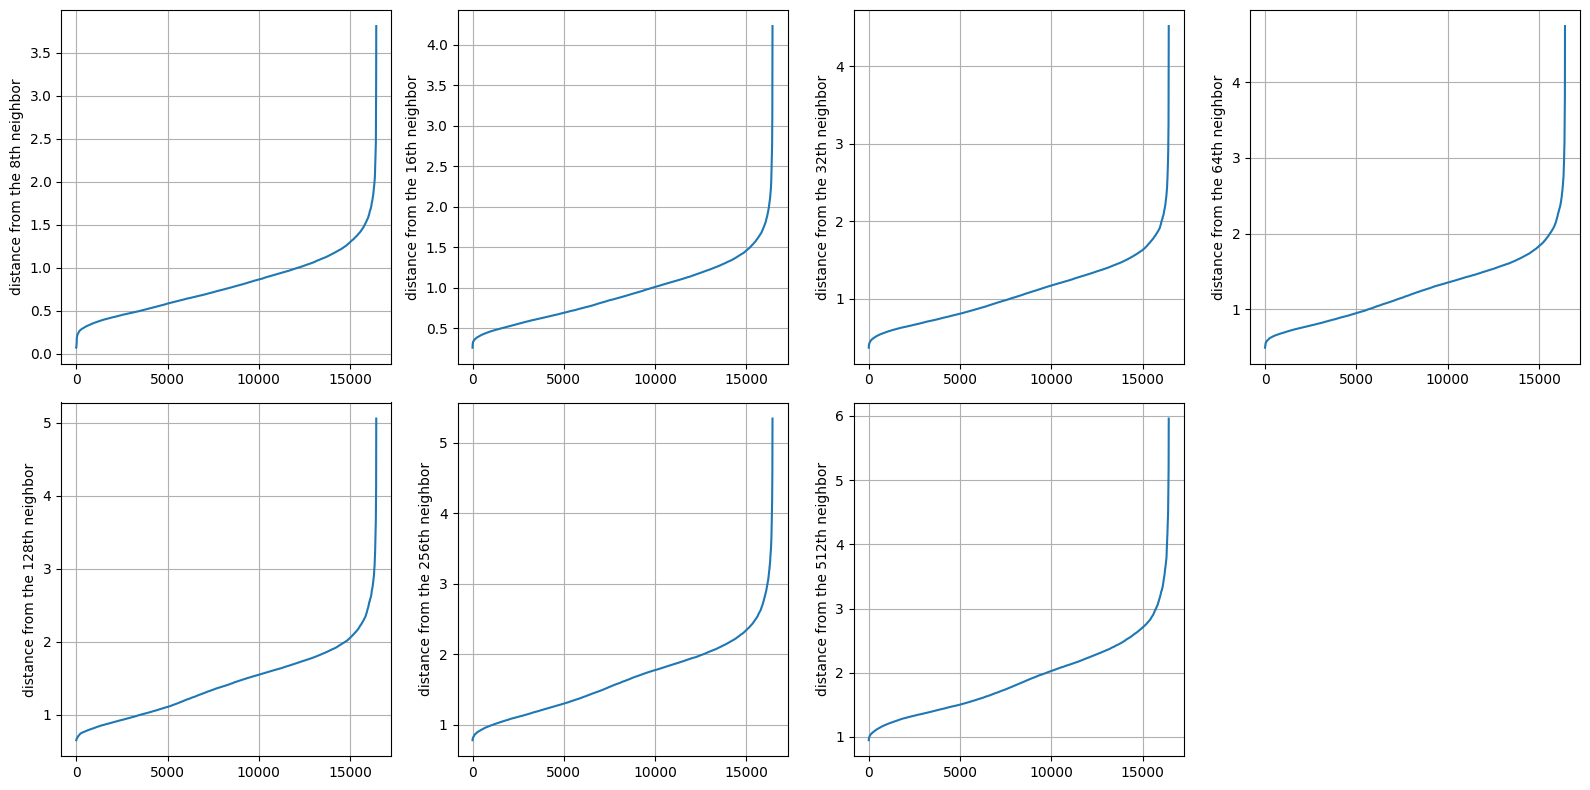

In [15]:
fig = plt.figure(figsize=(16, 8))
fig_dims = ((len(kth_distances) // 4) + 1, 4)

for i, k in enumerate(ks):
    distances = kth_distances[k]
    x = range(len(distances))
    y = sorted(distances)

    plt.subplot2grid(fig_dims, (i//4, i%4))
    plt.plot(x, y)
    plt.grid()
    plt.ylabel(f'distance from the {k}th neighbor')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'distance from the 16th neighbor')

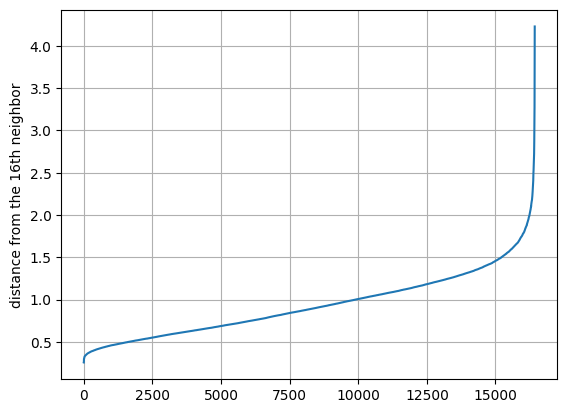

In [71]:
k = 16
distances = kth_distances[k]
x = range(len(distances))
y = sorted(distances)

plt.plot(x, y)
plt.grid()
plt.ylabel(f'distance from the {k}th neighbor')

## Clustering
### DBSCAN

In [16]:
%%time

dbscan = DBSCAN(eps=1.3, min_samples=16, metric='precomputed')
dbscan.fit(distance_matrix)

CPU times: user 1.7 s, sys: 6.91 s, total: 8.61 s
Wall time: 24.7 s


DBSCAN(eps=1.3, metric='precomputed', min_samples=16)

In [17]:
np.unique(dbscan.labels_, return_counts=True)

(array([-1,  0]), array([  712, 15719]))

Only one cluster, no silhouette score.

### OPTICS

In [18]:
%%time

optics = OPTICS(min_samples=16, metric='euclidean', n_jobs=-1)
optics.fit(numeric_df)

CPU times: user 1min 4s, sys: 25.4 s, total: 1min 29s
Wall time: 3min 53s


OPTICS(metric='euclidean', min_samples=16, n_jobs=-1)

In [19]:
np.unique(optics.labels_, return_counts=True)

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 array([16135,    21,    32,    19,    26,    27,    19,    40,    19,
           24,    24,    19,    26]))

In [20]:
labels_optics = optics.labels_
inliers = labels_optics != -1

In [21]:
distance_inliers = distance_matrix[np.ix_(inliers, inliers)]
distance_inliers.shape

(296, 296)

In [22]:
silhouette_score(distance_inliers, labels_optics[inliers], metric='precomputed')

np.float64(0.6694476300335513)

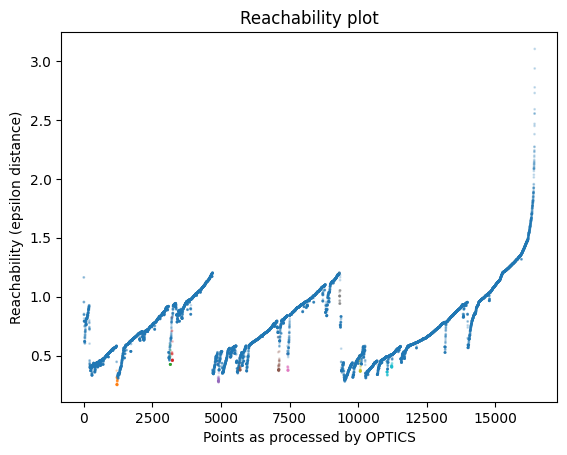

In [23]:
space = np.arange(len(df))
reachability = optics.reachability_[optics.ordering_]
labels = optics.labels_[optics.ordering_]
plt.title("Reachability plot")
plt.ylabel("Reachability (epsilon distance)")
plt.xlabel("Points as processed by OPTICS")

plt.scatter(space, reachability, alpha=.2, s=1, c=labels, cmap='tab10')

The reachability plot doesn't really show any valleys, which explains why both dbscan and optics fail to detect significative clusters in the data.

We can attempt extract clusters setting eps to 1.2.

In [24]:
labels_102 = cluster_optics_dbscan(
    reachability=optics.reachability_,
    core_distances=optics.core_distances_,
    ordering=optics.ordering_,
    eps=1.2
)

np.unique(labels_102, return_counts=True)

(array([-1,  0,  1,  2]), array([1188, 4684, 4614, 5945]))

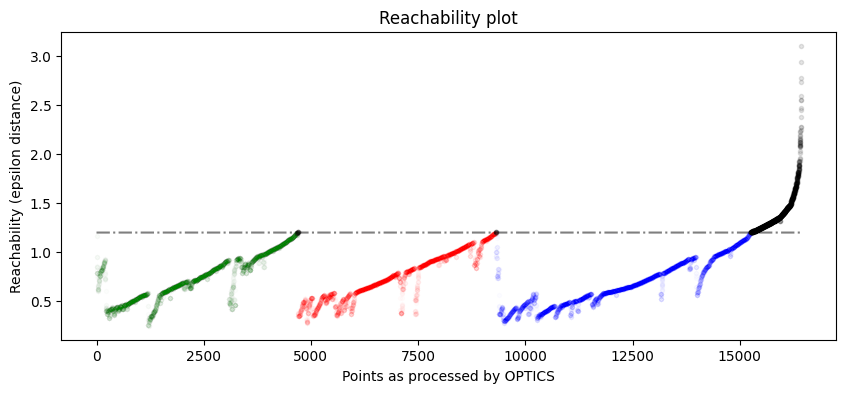

In [43]:
space = np.arange(len(df))
plt.figure(figsize=(10, 4))
reachability = optics.reachability_[optics.ordering_]
labels = labels_102[optics.ordering_]
plt.title("Reachability plot")
plt.ylabel("Reachability (epsilon distance)")
plt.xlabel("Points as processed by OPTICS")
plt.plot(space, np.full_like(space, 1.2, dtype=float), "k-.", alpha=0.5)

colors = ["g.", "r.", "b."]
for klass, color in enumerate(colors):
    plt.plot(space[labels == klass], reachability[labels == klass], color, alpha=0.01)
plt.plot(space[labels == -1], reachability[labels == -1], "k.", alpha=0.1)

In [26]:
inliers = labels_102 != -1

In [27]:
distance_inliers = distance_matrix[np.ix_(inliers, inliers)]
distance_inliers.shape

(15243, 15243)

In [28]:
silhouette_score(distance_inliers, labels_102[inliers], metric='precomputed')

np.float64(0.08990998448261184)

In [56]:
df_clusters = df[numeric_cols]
df_clusters['labels'] = pd.Categorical(labels_optics)
df_clusters['labels_102'] = pd.Categorical(labels_102)

/tmp/ipykernel_197741/1915567891.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters['labels'] = pd.Categorical(labels_optics)
/tmp/ipykernel_197741/1915567891.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clusters['labels_102'] = pd.Categorical(labels_102)


In [49]:
import seaborn as sns

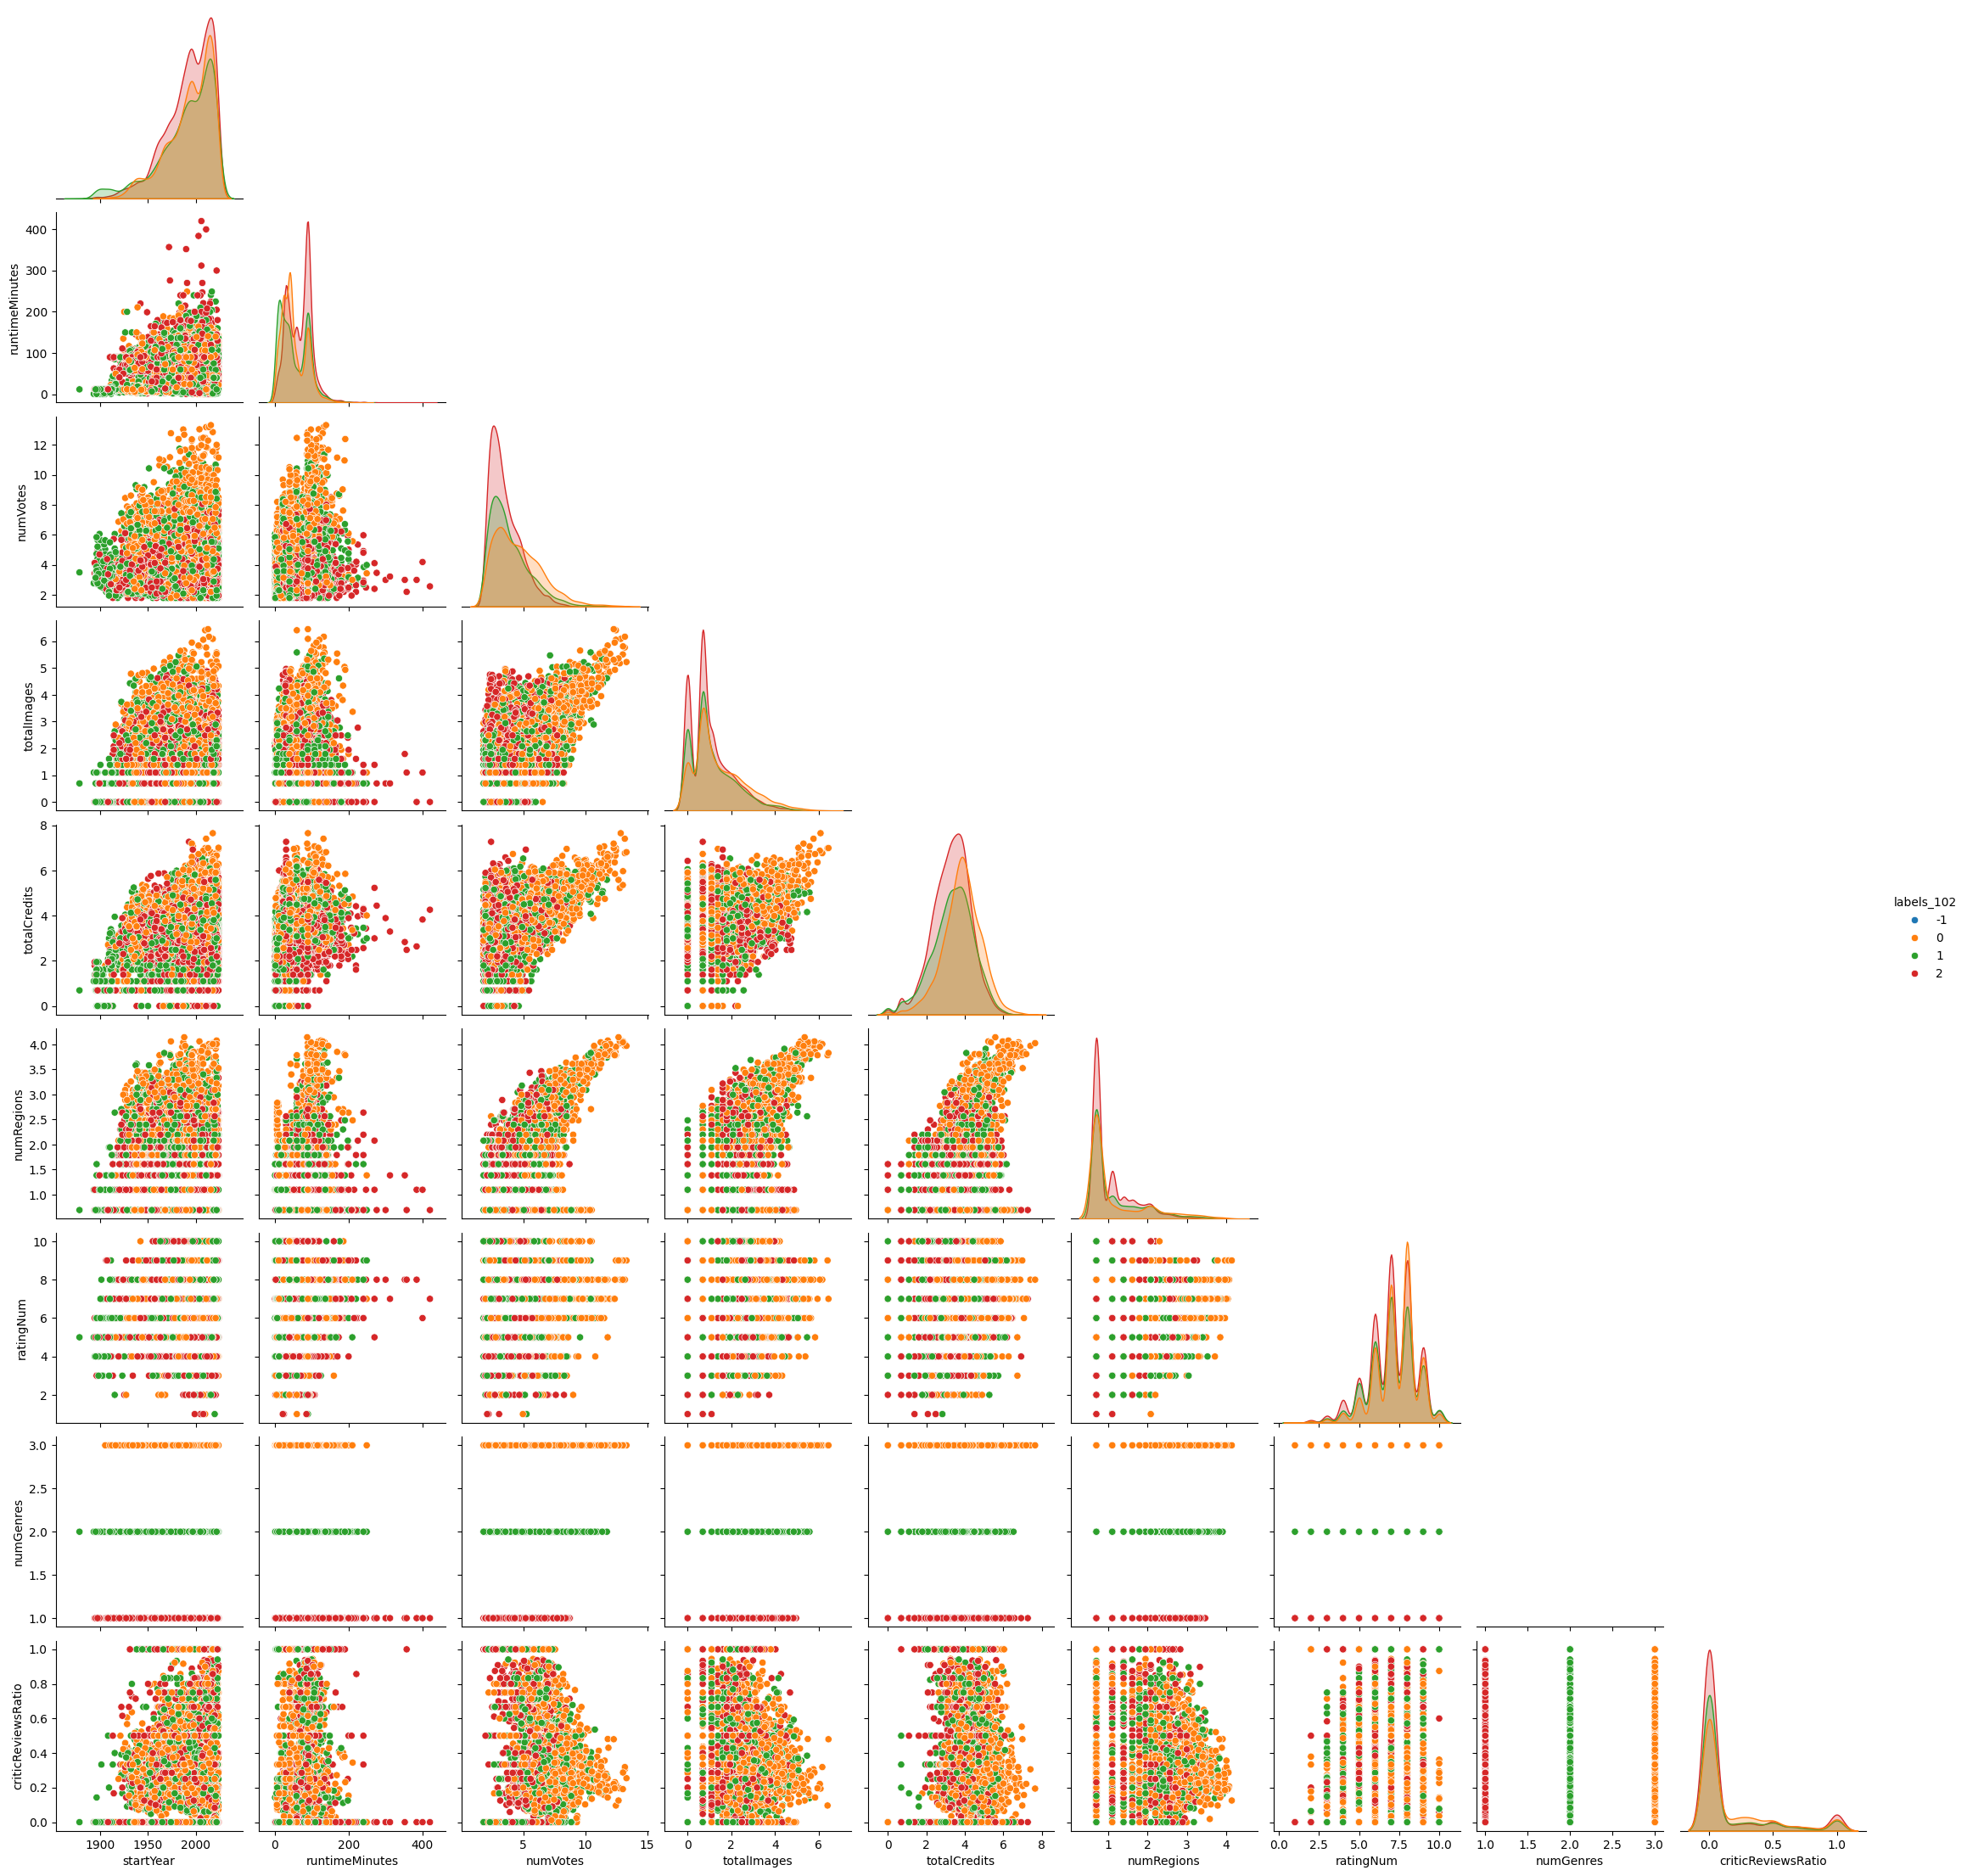

In [67]:
sns.pairplot(df_clusters[df_clusters['labels_102'] != -1], diag_kind="kde", corner=True, hue='labels_102')